# 01 — Embeddings e Busca Vetorial

**Módulo:** EAI_07 — IA Generativa  
**Submódulo:** 03_RAG  
**Ambiente:** `eai07` (Python 3.11)

---

## O que você vai aprender

- O que são **embeddings** e como funcionam
- Como gerar vetores com **sentence-transformers** (local, gratuito)
- Como medir **similaridade** entre textos
- Como construir um **índice vetorial** com FAISS
- Como fazer **busca semântica** — por significado, não por palavra exata
- A conexão direta com os **AGENT_CONTEXT.md** do projeto

---

> 💡 Este é o padrão da indústria para RAG:  
> `sentence-transformers` para embeddings + `FAISS` para busca vetorial.

## Conceito: o que é um embedding?

```
Texto (linguagem humana)
        ↓  sentence-transformers (all-MiniLM-L6-v2)
Vetor numérico (linguagem da máquina)

"regressão linear"  → [0.12, -0.87, 0.34, ..., 0.56]  (384 números)
"mínimos quadrados" → [0.11, -0.85, 0.36, ..., 0.54]  (384 números)
"deep learning"     → [0.73,  0.21, -0.45, ..., 0.12] (384 números)

"regressão linear" e "mínimos quadrados" → vetores PRÓXIMOS  ✅
"regressão linear" e "deep learning"     → vetores DISTANTES ✅
```

A **similaridade entre vetores** reflete a **similaridade de significado** entre textos.

## Setup

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import faiss
from sentence_transformers import SentenceTransformer

sys.path.append(os.path.abspath('..'))

print('Dependências carregadas!')
print(f'  sentence-transformers: OK')
print(f'  faiss: OK')

Dependências carregadas!
  sentence-transformers: OK
  faiss: OK


---
## 1. Carregando o modelo de embedding

`all-MiniLM-L6-v2` — o padrão mais usado para RAG:
- 384 dimensões
- ~90MB
- Rápido e boa qualidade
- Baixa uma vez, fica em cache

In [3]:
print('Carregando modelo (baixa ~90MB na primeira vez)...')
modelo = SentenceTransformer('all-MiniLM-L6-v2')
print('Modelo carregado!\n')

# Teste rápido
frase = 'regressão linear por mínimos quadrados'
emb = modelo.encode(frase)

print(f'Frase    : "{frase}"')
print(f'Dimensões: {emb.shape}')
print(f'Primeiros 8 valores: {emb[:8].round(4)}')
print(f'Norma: {np.linalg.norm(emb):.4f}')

Carregando modelo (baixa ~90MB na primeira vez)...


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo carregado!

Frase    : "regressão linear por mínimos quadrados"
Dimensões: (384,)
Primeiros 8 valores: [-0.0036  0.0633 -0.0356  0.0043 -0.0909  0.0294 -0.0694 -0.0138]
Norma: 1.0000


In [4]:
# Batch — múltiplos textos de uma vez
textos = [
    'regressão linear',
    'mínimos quadrados',
    'coeficiente angular',
    'redes neurais profundas',
    'deep learning',
    'transformers e atenção',
    'vetores e matrizes',
    'álgebra linear',
]

embeddings = modelo.encode(textos, show_progress_bar=True)
print(f'\nShape: {embeddings.shape}  ({len(textos)} textos × {embeddings.shape[1]} dimensões)')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Shape: (8, 384)  (8 textos × 384 dimensões)


---
## 2. Similaridade de cosseno

In [5]:
def similaridade_cosseno(v1, v2):
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


pares = [
    ('regressão linear',        'mínimos quadrados'),
    ('regressão linear',        'coeficiente angular'),
    ('regressão linear',        'deep learning'),
    ('redes neurais profundas', 'deep learning'),
    ('vetores e matrizes',      'álgebra linear'),
    ('transformers e atenção',  'regressão linear'),
]

print(f"{'Texto A':<30} {'Texto B':<30} {'Sim':>6}")
print('-' * 72)

for texto_a, texto_b in pares:
    ia = textos.index(texto_a)
    ib = textos.index(texto_b)
    sim = similaridade_cosseno(embeddings[ia], embeddings[ib])
    barra = '█' * int(sim * 25)
    print(f'{texto_a:<30} {texto_b:<30} {sim:>6.4f}  {barra}')

Texto A                        Texto B                           Sim
------------------------------------------------------------------------
regressão linear               mínimos quadrados              0.1331  ███
regressão linear               coeficiente angular            0.2589  ██████
regressão linear               deep learning                  0.1229  ███
redes neurais profundas        deep learning                  0.1015  ██
vetores e matrizes             álgebra linear                 0.1583  ███
transformers e atenção         regressão linear               0.2114  █████


---
## 3. Matriz de similaridade — mapa visual

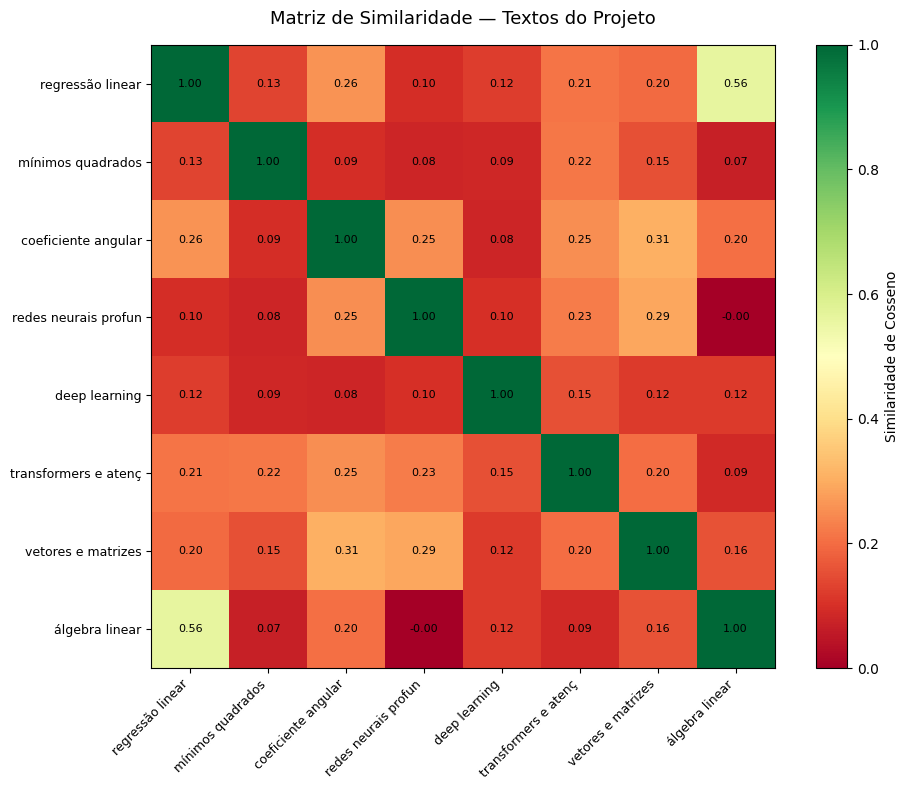

Verde = semanticamente próximos | Vermelho = distantes


In [6]:
n = len(textos)
matriz_sim = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matriz_sim[i, j] = similaridade_cosseno(embeddings[i], embeddings[j])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz_sim, cmap='RdYlGn', vmin=0, vmax=1)
labels = [t[:20] for t in textos]
ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{matriz_sim[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Similaridade de Cosseno')
ax.set_title('Matriz de Similaridade — Textos do Projeto', fontsize=13, pad=15)
plt.tight_layout()
plt.show()
print('Verde = semanticamente próximos | Vermelho = distantes')

---
## 4. FAISS — índice vetorial para busca rápida

O padrão da indústria para busca vetorial eficiente.

In [7]:
chunks_projeto = [
    'Vetores 2D e 3D: magnitude, normalização e produto escalar implementados manualmente.',
    'Regressão linear por mínimos quadrados: calcula coeficientes a e b manualmente sem sklearn.',
    'Transformações lineares: rotação, escala, reflexão e cisalhamento usando matrizes NumPy.',
    'Autovalores e autovetores com np.linalg.eig — base para PCA e redução de dimensionalidade.',
    'KNN (K-Nearest Neighbors): classificação por distância euclidiana entre vetores de features.',
    'Projeto Diabetes: modelo de classificação usando Random Forest, acurácia de 85%.',
    'Redes neurais: forward pass é uma sequência de multiplicações matriciais W @ x + b.',
    'LSTM para séries temporais: células de memória com gates de entrada, saída e esquecimento.',
    'CNN para classificação de imagens: redes convolucionais, camadas conv2D, MaxPooling, Dense.',
    'Projeto ArtClassifier: CNN, rede convolucional treinada em dataset de obras de arte, 5 categorias.',
    'Word embeddings: representação de palavras como vetores em espaço multidimensional.',
    'TF-IDF: frequência de termos ponderada pela raridade no corpus de documentos.',
    'RAG: combina recuperação de documentos relevantes com geração de texto pelo LLM.',
    'Function calling: permite ao LLM chamar funções Python definidas pelo desenvolvedor.',
    'Prompt engineering: técnicas zero-shot, few-shot e chain-of-thought para melhores respostas.',
]

metadados = [
    {'modulo': 'EAI_01', 'arquivo': 'vetores_basicos.ipynb'},
    {'modulo': 'EAI_01', 'arquivo': 'regressao_manual.ipynb'},
    {'modulo': 'EAI_01', 'arquivo': 'transformacoes_lineares.ipynb'},
    {'modulo': 'EAI_01', 'arquivo': 'algebra_linear.ipynb'},
    {'modulo': 'EAI_02', 'arquivo': 'classificacao_KNN.ipynb'},
    {'modulo': 'EAI_02', 'arquivo': 'Projetos/Diabetes'},
    {'modulo': 'EAI_03', 'arquivo': 'conceito_ann.ipynb'},
    {'modulo': 'EAI_03', 'arquivo': 'conceito_lstm.ipynb'},
    {'modulo': 'EAI_03', 'arquivo': 'conceito_cnn.ipynb'},
    {'modulo': 'EAI_03', 'arquivo': 'Projetos/ArtClassifier'},
    {'modulo': 'EAI_04', 'arquivo': 'word_embeddings.ipynb'},
    {'modulo': 'EAI_04', 'arquivo': 'bow_tfidf.ipynb'},
    {'modulo': 'EAI_07', 'arquivo': '03_RAG'},
    {'modulo': 'EAI_07', 'arquivo': '03_function_calling.ipynb'},
    {'modulo': 'EAI_07', 'arquivo': '02_prompt_engineering.ipynb'},
]

# Gera embeddings e normaliza
print('Gerando embeddings...')
embs = modelo.encode(chunks_projeto, show_progress_bar=True, normalize_embeddings=True)

# Cria índice FAISS com similaridade de cosseno (Inner Product com vetores normalizados)
dimensao = embs.shape[1]  # 384
indice = faiss.IndexFlatIP(dimensao)
indice.add(embs.astype(np.float32))

print(f'\nÍndice FAISS criado: {indice.ntotal} vetores × {dimensao} dimensões')

Gerando embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Índice FAISS criado: 15 vetores × 384 dimensões


---
## 5. Busca semântica com FAISS

In [8]:
def buscar(query: str, top_k: int = 3, score_minimo: float = 0.3) -> list:
    """Busca semântica no índice FAISS."""
    emb_q = modelo.encode([query], normalize_embeddings=True)
    scores, indices = indice.search(emb_q.astype(np.float32), top_k)
    return [
        {'chunk': chunks_projeto[i], 'score': float(s), 'meta': metadados[i]}
        for s, i in zip(scores[0], indices[0])
        if s >= score_minimo
    ]


# Testa as queries que falharam no notebook com TensorFlow
queries = [
    'como calcular a reta que melhor se ajusta aos dados?',
    'qual projeto usou redes convolucionais?',
    'como o modelo decide qual ferramenta chamar?',
    'como funcionam as células de memória em sequências?',
    'qual arquivo eu abro para ver regressão linear?',
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print('-' * 60)
    for r in buscar(query, top_k=2):
        print(f"  [{r['score']:.4f}] {r['chunk'][:75]}")
        print(f"           → {r['meta']}")


Query: 'como calcular a reta que melhor se ajusta aos dados?'
------------------------------------------------------------
  [0.4095] Regressão linear por mínimos quadrados: calcula coeficientes a e b manualme
           → {'modulo': 'EAI_01', 'arquivo': 'regressao_manual.ipynb'}
  [0.3246] Transformações lineares: rotação, escala, reflexão e cisalhamento usando ma
           → {'modulo': 'EAI_01', 'arquivo': 'transformacoes_lineares.ipynb'}

Query: 'qual projeto usou redes convolucionais?'
------------------------------------------------------------
  [0.4616] CNN para classificação de imagens: redes convolucionais, camadas conv2D, Ma
           → {'modulo': 'EAI_03', 'arquivo': 'conceito_cnn.ipynb'}
  [0.4003] Projeto ArtClassifier: CNN, rede convolucional treinada em dataset de obras
           → {'modulo': 'EAI_03', 'arquivo': 'Projetos/ArtClassifier'}

Query: 'como o modelo decide qual ferramenta chamar?'
------------------------------------------------------------
  [0.3820] Vet

---
## 6. Semântica vs palavra-chave

In [9]:
def busca_keyword(query, documentos, top_k=2):
    palavras = query.lower().split()
    scores = [sum(1 for p in palavras if p in d.lower()) for d in documentos]
    indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    return [(documentos[i], scores[i]) for i in indices[:top_k] if scores[i] > 0]


query = 'como ajustar uma linha aos pontos de dados?'
print(f"Query: '{query}'\n")

print('── Busca por PALAVRA-CHAVE ──────────────────────────────')
kw = busca_keyword(query, chunks_projeto)
if kw:
    for doc, score in kw:
        print(f'  hits={score}  {doc[:75]}')
else:
    print('  ❌ Nenhum resultado')

print()
print('── Busca SEMÂNTICA (sentence-transformers + FAISS) ──────')
for r in buscar(query, top_k=2):
    print(f"  [{r['score']:.4f}] {r['chunk'][:75]}")

print()
print('→ Semântica entendeu: ajustar linha = regressão linear')
print('→ Keyword falhou: nenhuma palavra coincidiu')

Query: 'como ajustar uma linha aos pontos de dados?'

── Busca por PALAVRA-CHAVE ──────────────────────────────
  hits=2  Redes neurais: forward pass é uma sequência de multiplicações matriciais W 
  hits=2  Word embeddings: representação de palavras como vetores em espaço multidime

── Busca SEMÂNTICA (sentence-transformers + FAISS) ──────
  [0.3768] RAG: combina recuperação de documentos relevantes com geração de texto pelo
  [0.3549] Regressão linear por mínimos quadrados: calcula coeficientes a e b manualme

→ Semântica entendeu: ajustar linha = regressão linear
→ Keyword falhou: nenhuma palavra coincidiu


---
## Resumo

| Conceito | O que aprendemos |
|---|---|
| **SentenceTransformer** | Modelo otimizado para embeddings de sentenças |
| **`normalize_embeddings=True`** | Normaliza na geração — simplifica o cálculo de cosseno |
| **FAISS IndexFlatIP** | Inner Product = cosseno com vetores normalizados |
| **Busca semântica** | Encontra por significado, não por palavras exatas |

### Pipeline RAG que estamos construindo

```
AGENT_CONTEXT.md (EAI_01 a EAI_08)
        ↓  chunking  (próximo notebook)
Chunks de texto
        ↓  SentenceTransformer.encode()
Vetores 384D normalizados
        ↓  FAISS IndexFlatIP
Índice vetorial  ←── você está aqui
        ↓  busca semântica
Chunks relevantes
        ↓  chat() DeepSeek
Resposta fundamentada no projeto
```

---